In [1]:
import pandas as pd

In [2]:
import os
print("Current working directory =", os.getcwd())

Current working directory = c:\Customer_Churn_Project\notebooks


In [3]:
df=pd.read_csv('c:\Customer_Churn_Project\data\customer_churn_records.csv')

<>:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
<>:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
C:\Users\Hp\AppData\Local\Temp\ipykernel_6460\2594299391.py:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
  df=pd.read_csv('c:\Customer_Churn_Project\data\customer_churn_records.csv')


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,OnlineSecurity,TechSupport,StreamingTV,Contract,PaymentMethod,MonthlyCharges,Churn
0,CUST100000,Male,0.0,Yes,No,6.0,Yes,Fiber optic,Yes,No internet service,No internet service,Two year,Mailed check,118.98,No
1,CUST100001,Female,0.0,Yes,No,68.0,NaN,NaN,No internet service,No internet service,Yes,One year,Electronic check,48.22,No
2,CUST100002,Female,0.0,No,Yes,37.0,No,DSL,Yes,No,Yes,Two year,Credit card (automatic),110.97,No
3,CUST100003,Male,0.0,Yes,No,71.0,Yes,DSL,No internet service,No,Yes,Two year,Electronic check,109.67,Yes
4,CUST100004,Male,0.0,Yes,No,29.0,Yes,DSL,Yes,NaN,No internet service,One year,Electronic check,105.22,No


In [5]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,OnlineSecurity,TechSupport,StreamingTV,Contract,PaymentMethod,MonthlyCharges,Churn
9995,CUST109995,Male,1.0,NaN,No,43.0,Yes,Fiber optic,No internet service,No internet service,NaN,Month-to-month,Mailed check,36.33,No
9996,CUST109996,Female,0.0,Yes,No,30.0,No,DSL,Yes,No internet service,No,Month-to-month,Electronic check,56.45,No
9997,CUST109997,Male,0.0,No,Yes,70.0,Yes,DSL,No,No internet service,No,Month-to-month,Mailed check,20.35,Yes
9998,CUST109998,Female,0.0,Yes,Yes,43.0,Yes,No,Yes,No internet service,Yes,One year,Bank transfer (automatic),28.26,Yes
9999,CUST109999,Female,1.0,Yes,No,11.0,Yes,DSL,No internet service,No,Yes,Month-to-month,NaN,63.50,No


In [6]:
df.shape
print(f"No of Rows Before data cleaning: {df.shape[0]}")
print(f"No of Columns Before data cleaning: {df.shape[1]}")

No of Rows Before data cleaning: 10000
No of Columns Before data cleaning: 15


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,9685.000000,9649.000000,9577.000000
mean,0.156118,35.578713,69.110209
std,0.362986,20.618712,29.337782
min,0.000000,0.000000,18.010000
25%,0.000000,18.000000,44.100000
50%,0.000000,35.000000,69.210000
75%,0.000000,53.000000,94.290000
max,1.000000,71.000000,119.990000


In [8]:
df.isnull().sum()

customerID           0
gender             226
SeniorCitizen      315
Partner            303
Dependents         458
tenure             351
PhoneService       202
InternetService    447
OnlineSecurity     402
TechSupport        221
StreamingTV        294
Contract           375
PaymentMethod      353
MonthlyCharges     423
Churn              255
dtype: int64

In [9]:
a=df.columns
for i in a:
    print(i," : ",df[i].unique())

customerID  :  ['CUST100000' 'CUST100001' 'CUST100002' ... 'CUST109997' 'CUST109998'
 'CUST109999']
gender  :  ['Male' 'Female' nan]
SeniorCitizen  :  [ 0.  1. nan]
Partner  :  ['Yes' 'No' nan]
Dependents  :  ['No' 'Yes' nan]
tenure  :  [ 6. 68. 37. 71. 29. 59. 23. 31. 24. 39. 16. 36. 60. 11. 57. 61.  2. 48.
 34. 45. 21. 15. 20. 62. 56. 12. 40.  5.  4. nan 50.  8. 51. 14. 66. 43.
 22. 64. 63. 32. 44. 55. 13. 10. 58. 70.  0. 19. 38. 49. 46.  9. 26. 35.
 67.  7. 25. 69.  3. 42. 47. 52. 54. 28.  1. 17. 41. 53. 30. 65. 18. 33.
 27.]
PhoneService  :  ['Yes' nan 'No']
InternetService  :  ['Fiber optic' nan 'DSL' 'No']
OnlineSecurity  :  ['Yes' 'No internet service' 'No' nan]
TechSupport  :  ['No internet service' 'No' nan 'Yes']
StreamingTV  :  ['No internet service' 'Yes' 'No' nan]
Contract  :  ['Two year' 'One year' 'Month-to-month' nan]
PaymentMethod  :  ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)' nan]
MonthlyCharges  :  [118.98  48.22 110.97 

In [10]:
df=df.drop(columns=['customerID'])

In [11]:
# Lets Clean The Data
df['gender']=df['gender'].fillna(df['gender'].mode()[0])

df['SeniorCitizen']=df['SeniorCitizen'].fillna(df['SeniorCitizen'].mode()[0]).astype('int')

df['Partner']=df['Partner'].fillna(df['Partner'].mode()[0])

df['Dependents']=df['Dependents'].fillna('No')

df['tenure']=df['tenure'].fillna(df['tenure'].median())

df['PhoneService']=df['PhoneService'].fillna(df['PhoneService'].mode()[0])

df['InternetService']=df['InternetService'].fillna(df['InternetService'].mode()[0])

df['Contract']=df['Contract'].fillna(df['Contract'].mode()[0])

df['PaymentMethod']=df['PaymentMethod'].fillna(df['PaymentMethod'].mode()[0])

df['MonthlyCharges'] = df['MonthlyCharges'].fillna(df['MonthlyCharges'].mean())

df['tenure'] = df['tenure'].astype('int')

In [12]:
# Replacing 'No internet Service' with 'No'----

df['OnlineSecurity']=df['OnlineSecurity'].replace('No internet service','No')
df['OnlineSecurity']=df['OnlineSecurity'].fillna(df['OnlineSecurity'].mode()[0])

df['TechSupport']=df['TechSupport'].replace('No internet service','No')
df['TechSupport']=df['TechSupport'].fillna(df['TechSupport'].mode()[0])

df['StreamingTV']=df['StreamingTV'].replace('No internet service','No')
df['StreamingTV']=df['StreamingTV'].fillna(df['StreamingTV'].mode()[0])

In [13]:
print(df.isna().sum())

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
InternetService      0
OnlineSecurity       0
TechSupport          0
StreamingTV          0
Contract             0
PaymentMethod        0
MonthlyCharges       0
Churn              255
dtype: int64


In [14]:
df = df.dropna(subset=['Churn'])
print(df.isna().sum())

gender             0
SeniorCitizen      0
Partner            0
Dependents         0
tenure             0
PhoneService       0
InternetService    0
OnlineSecurity     0
TechSupport        0
StreamingTV        0
Contract           0
PaymentMethod      0
MonthlyCharges     0
Churn              0
dtype: int64


In [15]:
df.shape
print(f"No of Rows after data cleaning: {df.shape[0]}")
print(f"No of Columns after data cleaning: {df.shape[1]}")

No of Rows after data cleaning: 9745
No of Columns after data cleaning: 14


In [16]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,OnlineSecurity,TechSupport,StreamingTV,Contract,PaymentMethod,MonthlyCharges,Churn
0,Male,0,Yes,No,6,Yes,Fiber optic,Yes,No,No,Two year,Mailed check,118.98,No
1,Female,0,Yes,No,68,Yes,No,No,No,Yes,One year,Electronic check,48.22,No
2,Female,0,No,Yes,37,No,DSL,Yes,No,Yes,Two year,Credit card (automatic),110.97,No
3,Male,0,Yes,No,71,Yes,DSL,No,No,Yes,Two year,Electronic check,109.67,Yes
4,Male,0,Yes,No,29,Yes,DSL,Yes,No,No,One year,Electronic check,105.22,No


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style("whitegrid")

Churn
No     0.725398
Yes    0.274602
Name: proportion, dtype: float64


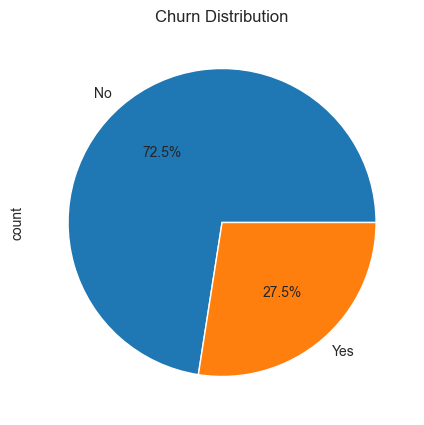

In [18]:
print(df['Churn'].value_counts(normalize=True))
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(5,5))
plt.title("Churn Distribution")
plt.show()

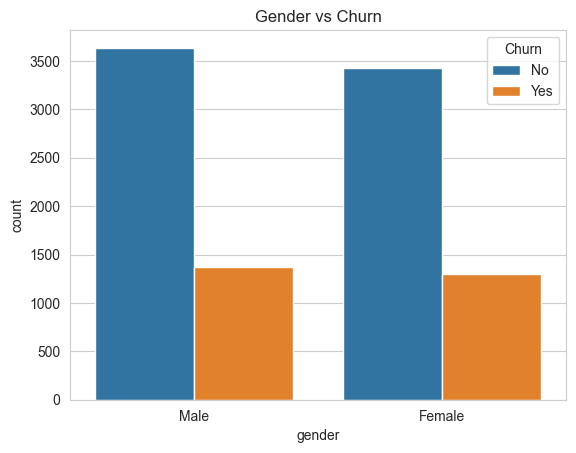

gender  Churn
Female  No       0.724662
        Yes      0.275338
Male    No       0.726093
        Yes      0.273907
Name: proportion, dtype: float64


In [19]:
sns.countplot(x='gender', hue='Churn', data=df)
plt.title("Gender vs Churn")
plt.show()

print(df.groupby('gender')['Churn'].value_counts(normalize=True))

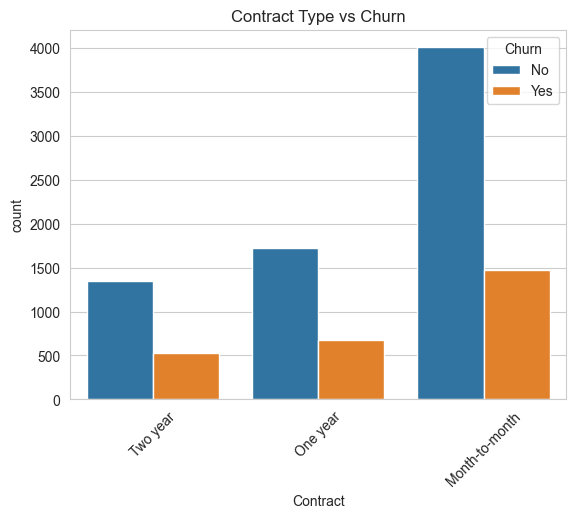

Contract        Churn
Month-to-month  No       0.730573
                Yes      0.269427
One year        No       0.718580
                Yes      0.281420
Two year        No       0.718951
                Yes      0.281049
Name: proportion, dtype: float64


In [20]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title("Contract Type vs Churn")
plt.show()

print(df.groupby('Contract')['Churn'].value_counts(normalize=True))

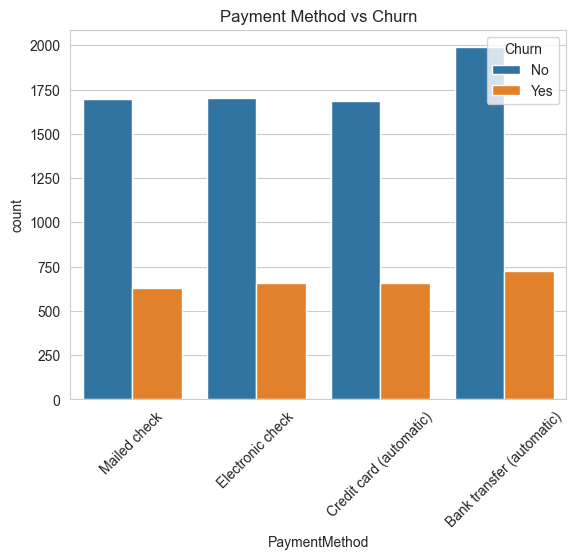

PaymentMethod              Churn
Bank transfer (automatic)  No       0.732768
                           Yes      0.267232
Credit card (automatic)    No       0.718857
                           Yes      0.281143
Electronic check           No       0.720576
                           Yes      0.279424
Mailed check               No       0.728289
                           Yes      0.271711
Name: proportion, dtype: float64


In [21]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title("Payment Method vs Churn")
plt.show()

print(df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True))

In [22]:
df.dtypes
cat_col=df.select_dtypes(include='object')
cat_col

,gender,Partner,Dependents,PhoneService,InternetService,OnlineSecurity,TechSupport,StreamingTV,Contract,PaymentMethod,Churn
0,Male,Yes,No,Yes,Fiber optic,Yes,No,No,Two year,Mailed check,No
1,Female,Yes,No,Yes,No,No,No,Yes,One year,Electronic check,No
2,Female,No,Yes,No,DSL,Yes,No,Yes,Two year,Credit card (automatic),No
3,Male,Yes,No,Yes,DSL,No,No,Yes,Two year,Electronic check,Yes
4,Male,Yes,No,Yes,DSL,Yes,No,No,One year,Electronic check,No
...,...,...,...,...,...,...,...,...,...,...,...
9995,Male,No,No,Yes,Fiber optic,No,No,No,Month-to-month,Mailed check,No
9996,Female,Yes,No,No,DSL,Yes,No,No,Month-to-month,Electronic check,No
9997,Male,No,Yes,Yes,DSL,No,No,No,Month-to-month,Mailed check,Yes
9998,Female,Yes,Yes,Yes,No,Yes,No,Yes,One year,Bank transfer (automatic),Yes


In [23]:
from sklearn.preprocessing import LabelEncoder
label_encoders = {}

for col in cat_col:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le


In [24]:
df.dtypes

gender               int64
SeniorCitizen        int64
Partner              int64
Dependents           int64
tenure               int64
PhoneService         int64
InternetService      int64
OnlineSecurity       int64
TechSupport          int64
StreamingTV          int64
Contract             int64
PaymentMethod        int64
MonthlyCharges     float64
Churn                int64
dtype: object

In [25]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,OnlineSecurity,TechSupport,StreamingTV,Contract,PaymentMethod,MonthlyCharges,Churn
0,1,0,1,0,6,1,1,1,0,0,2,3,118.98,0
1,0,0,1,0,68,1,2,0,0,1,1,2,48.22,0
2,0,0,0,1,37,0,0,1,0,1,2,1,110.97,0
3,1,0,1,0,71,1,0,0,0,1,2,2,109.67,1
4,1,0,1,0,29,1,0,1,0,0,1,2,105.22,0


In [26]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'InternetService', 'OnlineSecurity', 'TechSupport',
       'StreamingTV', 'Contract', 'PaymentMethod', 'MonthlyCharges', 'Churn'],
      dtype='object')

In [27]:
from sklearn.model_selection import train_test_split


In [28]:
X = df.drop(columns=['Churn'])  
y = df['Churn']                                

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y                     
)

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [31]:

rf_model = RandomForestClassifier(
    n_estimators=300,              # more trees help with imbalance
    # NO max_depth → let trees grow naturally
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'        # or try 'balanced_subsample'
)




In [32]:
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)



In [33]:

print("RF - unrestricted depth + balanced weights")
print("Accuracy:       ", round(accuracy_score(y_test, y_pred), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

RF - unrestricted depth + balanced weights
Accuracy:        0.6865

Confusion Matrix:
 [[1308  106]
 [ 505   30]]

Classification Report:

              precision    recall  f1-score   support

           0     0.7215    0.9250    0.8107      1414
           1     0.2206    0.0561    0.0894       535

    accuracy                         0.6865      1949
   macro avg     0.4710    0.4906    0.4500      1949
weighted avg     0.5840    0.6865    0.6127      1949



In [34]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))



Classification Report:

              precision    recall  f1-score   support

           0     0.7215    0.9250    0.8107      1414
           1     0.2206    0.0561    0.0894       535

    accuracy                         0.6865      1949
   macro avg     0.4710    0.4906    0.4500      1949
weighted avg     0.5840    0.6865    0.6127      1949



In [35]:
from sklearn.model_selection import GridSearchCV

In [36]:
param_grid_rf = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [None, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample', None]

}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

In [37]:
grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced', 'balanced_subsample', ...], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computat

In [38]:
print("Best CV Accuracy:", round(grid_rf.best_score_, 4))

Best CV Accuracy: 0.2763


In [39]:
best_rf = grid_rf.best_estimator_
y_pred_best = best_rf.predict(X_test)

In [ ]:

proba = best_rf.predict_proba(X_test)[:, 1]

for threshold in [0.45, 0.40, 0.35, 0.30, 0.25]:
    y_pred_custom = (proba >= threshold).astype(int)
    
    print(f"\n=== Threshold = {threshold} ===")
    print(classification_report(y_test, y_pred_custom, digits=4))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_custom))


=== Threshold = 0.45 ===
              precision    recall  f1-score   support

           0     0.7141    0.4010    0.5136      1414
           1     0.2667    0.5757    0.3645       535

    accuracy                         0.4489      1949
   macro avg     0.4904    0.4883    0.4390      1949
weighted avg     0.5913    0.4489    0.4727      1949

Confusion Matrix:
[[567 847]
 [227 308]]

=== Threshold = 0.4 ===
              precision    recall  f1-score   support

           0     0.6846    0.1351    0.2256      1414
           1     0.2677    0.8355    0.4054       535

    accuracy                         0.3273      1949
   macro avg     0.4761    0.4853    0.3155      1949
weighted avg     0.5701    0.3273    0.2750      1949

Confusion Matrix:
[[ 191 1223]
 [  88  447]]

=== Threshold = 0.35 ===
              precision    recall  f1-score   support

           0     0.7037    0.0403    0.0763      1414
           1     0.2736    0.9551    0.4253       535

    accuracy       

In [43]:
print("\nTuned Random Forest")
print("Test Accuracy:  ", round(accuracy_score(y_test, y_pred_best), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best, digits=4))


Tuned Random Forest
Test Accuracy:   0.607

Confusion Matrix:
 [[1066  348]
 [ 418  117]]

Classification Report:

              precision    recall  f1-score   support

           0     0.7183    0.7539    0.7357      1414
           1     0.2516    0.2187    0.2340       535

    accuracy                         0.6070      1949
   macro avg     0.4850    0.4863    0.4848      1949
weighted avg     0.5902    0.6070    0.5980      1949



In [44]:
print("Train set - Churn distribution:")
print(y_train.value_counts(normalize=True).round(4) * 100)

print("\nTest set - Churn distribution:")
print(y_test.value_counts(normalize=True).round(4) * 100)

print("\nWhat is 1 ? →", y_train.value_counts().index.tolist())

Train set - Churn distribution:
Churn
0    72.54
1    27.46
Name: proportion, dtype: float64

Test set - Churn distribution:
Churn
0    72.55
1    27.45
Name: proportion, dtype: float64

What is 1 ? → [0, 1]


In [45]:
import pickle
import os

os.makedirs("models", exist_ok=True)

# Save model
with open("models/churn_model.pkl", "wb") as f:
    pickle.dump(best_rf, f)   # your tuned model

# Save the chosen threshold (optional but useful)
chosen_threshold = 0.45

with open("models/chosen_threshold.pkl", "wb") as f:
    pickle.dump(chosen_threshold, f)

print("Model and threshold saved!")

Model and threshold saved!
